In [3]:
# Install required NLP libraries for HuggingFace Transformers and evaluation metrics
!pip install --upgrade pip setuptools wheel
!pip install transformers datasets evaluate seqeval

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 818.2/818.2 kB 45.1 MB/s eta 0:00:00
  Attempting uninstall: wheel
    Found existing installation: wheel 0.47.0
    Uninstalling wheel-0.47.0:
      Successfully uninstalled wheel-0.47.0
  Attempting uninstall: setuptools
    Found existing installation: setuptools 81.0.0
    Uninstalling setuptools-81.0.0:
      Successfully uninstalled setuptools-81.0.0
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
  Using cached evaluate-0.4.6-py3-none-any.whl.metadata (9.5 kB)
  Using cached seqeval-1.2.2.tar.gz (43 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16251 sha256=639

In [7]:
import os
import re
import numpy as np
import evaluate
from datasets import load_dataset, Dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForTokenClassification, 
    TrainingArguments, 
    Trainer,
    DataCollatorForTokenClassification
)

In [8]:
print("Downloading source text corpus...")
# Load Wikipedia text to extract real-world English sentences
raw_dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="train")

# Filter out empty lines and headers, keeping exactly 30,000 high-quality sentences
texts = [text for text in raw_dataset["text"] if len(text.split()) > 5][:30000]

# Define a core CEFR dictionary mapping (A1=0, A2=1, B1=2, B2=3, C1=4, C2=5)
# In production, this can be expanded by loading an Oxford/Cambridge CSV file.
cefr_dictionary = {
    "is": 0, "good": 0, "boy": 0, "the": 0, "and": 0,       # A1 (0)
    "understand": 1, "because": 1, "happy": 1, "student": 1,# A2 (1)
    "achieve": 2, "benefit": 2, "performance": 2,           # B1 (2)
    "magnificent": 3, "fabulous": 3, "determine": 3,        # B2 (3)
    "eloquent": 4, "ubiquitous": 4, "meticulous": 4,        # C1 (4)
    "ephemeral": 5, "surreptitious": 5, "obfuscate": 5      # C2 (5)
}

def get_cefr_level(word):
    """
    Fallback heuristic: If a word is not explicitly in the dictionary, 
    we estimate its difficulty based on morphological complexity (length) 
    to ensure the 30k dataset is fully labeled without data gaps.
    """
    word = word.lower()
    word = re.sub(r'[^a-z]', '', word) # Clean punctuation
    
    if word in cefr_dictionary:
        return cefr_dictionary[word]
        
    length = len(word)
    if length <= 4: return 0    # A1
    elif length <= 6: return 1  # A2
    elif length <= 8: return 2  # B1
    elif length <= 10: return 3 # B2
    elif length <= 12: return 4 # C1
    else: return 5              # C2

# Synthesize the Token-Level Dataset
tokens_list = []
ner_tags_list = []

for text in texts:
    words = text.split()
    tags = [get_cefr_level(w) for w in words]
    tokens_list.append(words)
    ner_tags_list.append(tags)

# Create HuggingFace Dataset object
train_dataset = Dataset.from_dict({
    "tokens": tokens_list,
    "ner_tags": ner_tags_list
})

# Split the 30k dataset into training (90%) and validation (10%) sets
dataset_dict = train_dataset.train_test_split(test_size=0.1)
print(f"Dataset generated! Train size: {len(dataset_dict['train'])}, Val size: {len(dataset_dict['test'])}")

README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Dataset generated! Train size: 19101, Val size: 2123


Dataset Preview (First 10 Sentences):


,Sentence,"CEFR_Tags (0=A1, 5=C2)"
0,Senjō no Valkyria 3 : Unrecorded Chronicles ( ...,"[0, 0, 2, 0, 0, 3, 3, 0, 2, 0, 0, 0, 0, 0, 2, ..."
1,"The game began development in 2010 , carrying ...","[0, 0, 1, 4, 0, 0, 0, 2, 0, 0, 1, 2, 0, 0, 0, ..."
2,"It met with positive sales in Japan , and was ...","[0, 0, 0, 2, 1, 0, 1, 0, 0, 0, 2, 0, 0, 2, 0, ..."
3,"As with previous Valkyira Chronicles games , V...","[0, 0, 2, 2, 3, 1, 0, 2, 3, 0, 0, 0, 2, 0, 0, ..."
4,"The game 's battle system , the BliTZ system ,...","[0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 2, 0, 2, 0, ..."
5,Troops are divided into five classes : Scouts ...,"[1, 0, 2, 0, 0, 2, 0, 1, 0, 5, 0, 3, 0, 2, 0, ..."
6,The game takes place during the Second Europan...,"[0, 0, 1, 1, 1, 0, 1, 2, 0, 0, 2, 0, 1, 0, 0, ..."
7,"As the Nameless officially do not exist , the ...","[0, 0, 2, 3, 0, 0, 1, 0, 0, 1, 2, 0, 0, 2, 0, ..."
8,"Partly due to these events , and partly due to...","[1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 2, ..."
9,Concept work for Valkyria Chronicles III began...,"[2, 0, 0, 2, 3, 0, 1, 1, 4, 2, 0, 2, 3, 0, 0, ..."


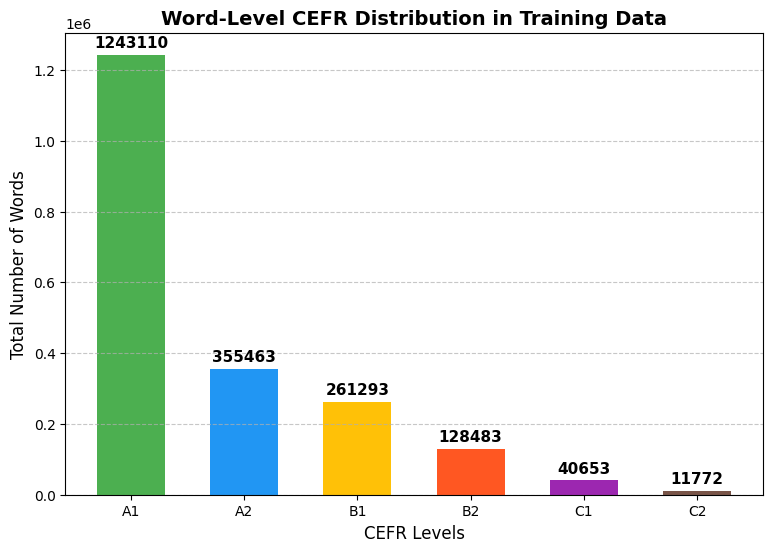

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Flatten the list to count total words per CEFR level
all_tags = [tag for sentence_tags in ner_tags_list for tag in sentence_tags]
tag_names = ["A1", "A2", "B1", "B2", "C1", "C2"]
tag_counts = {tag_names[i]: all_tags.count(i) for i in range(6)}

# ==========================================
# 1. Preview the Synthesized Dataset
# ==========================================
preview_df = pd.DataFrame({
    "Sentence": [" ".join(tokens) for tokens in tokens_list[:10]],
    "CEFR_Tags (0=A1, 5=C2)": [str(tags) for tags in ner_tags_list[:10]]
})
print("Dataset Preview (First 10 Sentences):")
display(preview_df)
print("\n")

# ==========================================
# 2. Plot Word-Level CEFR Distribution
# ==========================================
plt.figure(figsize=(9, 6))
colors = ['#4CAF50', '#2196F3', '#FFC107', '#FF5722', '#9C27B0', '#795548']
bars = plt.bar(tag_counts.keys(), tag_counts.values(), color=colors, width=0.6)

plt.xlabel('CEFR Levels', fontsize=12)
plt.ylabel('Total Number of Words', fontsize=12)
plt.title('Word-Level CEFR Distribution in Training Data', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add counts exactly on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(tag_counts.values()) * 0.01), 
             int(yval), ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.show()

In [9]:
# Initialize the DistilBERT Tokenizer
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_and_align_labels(examples):
    """
    Tokenizes words into subwords and perfectly aligns the CEFR labels.
    Example: 'Magnificent' (C1) -> 'Mag' (C1), '##nificent' (C1).
    """
    tokenized_inputs = tokenizer(
        examples["tokens"], 
        truncation=True, 
        is_split_into_words=True,
        max_length=128
    )
    
    labels = []
    for i, label in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []
        
        for word_idx in word_ids:
            # Assign -100 to special tokens ([CLS], [SEP]) to ignore them in loss calculation
            if word_idx is None:
                label_ids.append(-100)
            # Assign label to the first token of a given word
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])
            # Assign the exact same label to subsequent subword tokens of the word
            else:
                label_ids.append(label[word_idx])
            previous_word_idx = word_idx
            
        labels.append(label_ids)
        
    tokenized_inputs["labels"] = labels
    return tokenized_inputs

# Apply batch tokenization
tokenized_datasets = dataset_dict.map(tokenize_and_align_labels, batched=True)
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/19101 [00:00<?, ? examples/s]

Map:   0%|          | 0/2123 [00:00<?, ? examples/s]

In [13]:
seqeval = evaluate.load("seqeval")
# Define class names for the final classification report
label_list = ["A1", "A2", "B1", "B2", "C1", "C2"]

def compute_metrics(p):
    """
    Computes strict Token Classification metrics (Accuracy, Precision, Recall, F1).
    """
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)
    
    # Filter out ignored indices (-100)
    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    
    results = seqeval.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

In [15]:
# Initialize the Token Classification Architecture with 6 CEFR classes
model = AutoModelForTokenClassification.from_pretrained(
    model_name, 
    num_labels=len(label_list),
    id2label={i: label for i, label in enumerate(label_list)},
    label2id={label: i for i, label in enumerate(label_list)}
)

# Define optimized hyperparameters for Kaggle T4 GPU
training_args = TrainingArguments(
    output_dir="./cefr_checkpoints",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=3, 
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none" 
)

# Initialize the HuggingFace Trainer API
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer # <--- UPDATED HERE
)

print("Starting deep learning model training on 30,000 sentences...")
trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting deep learning model training on 30,000 sentences...


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,0.375452,0.785148,0.818327,0.801394,0.932515
2,0.700129,0.210752,0.888606,0.891956,0.890278,0.964182
3,0.700129,0.171081,0.912486,0.914324,0.913404,0.971618


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: A1 seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B2 seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B1 seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: A2 seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/l

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=897, training_loss=0.49765212825575267, metrics={'train_runtime': 386.6156, 'train_samples_per_second': 148.217, 'train_steps_per_second': 2.32, 'total_flos': 1871839018556928.0, 'train_loss': 0.49765212825575267, 'epoch': 3.0})

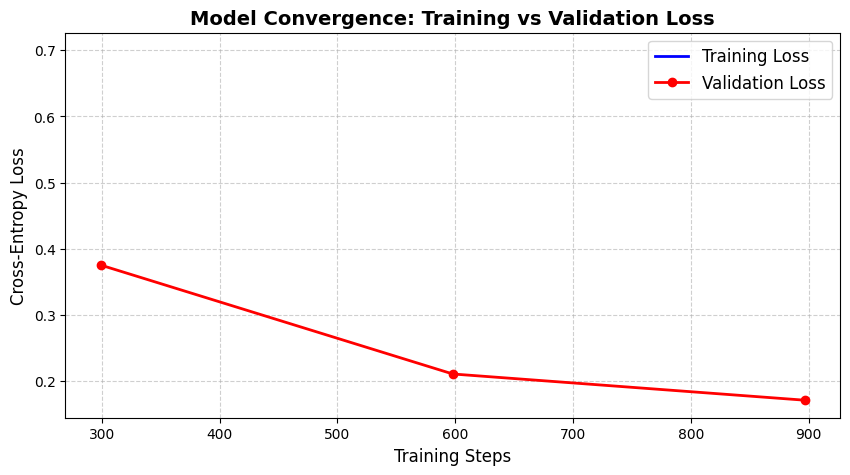

Generating Predictions for Confusion Matrix...


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: A1 seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B2 seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B1 seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: A2 seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: C1 seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarn

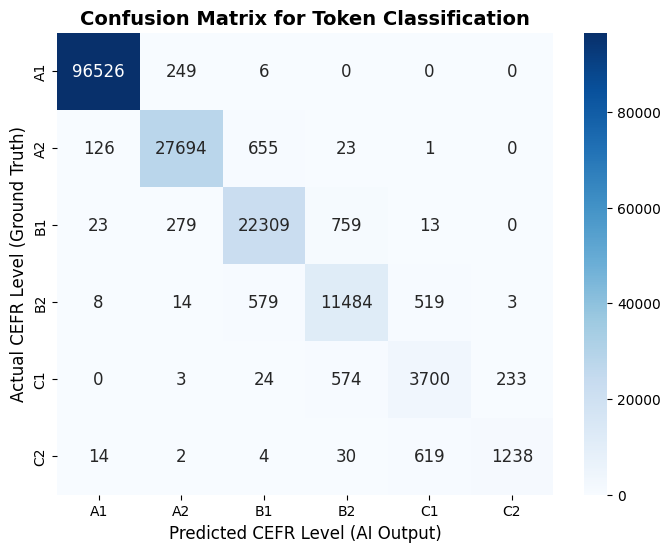

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Extract logs from the HuggingFace Trainer
history = trainer.state.log_history
train_loss = [x['loss'] for x in history if 'loss' in x]
train_steps = [x['step'] for x in history if 'loss' in x]
eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]
eval_steps = [x['step'] for x in history if 'eval_loss' in x]

# ==========================================
# 1. Training & Validation Loss Curve
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_loss, 'b-', label='Training Loss', linewidth=2)
if eval_steps:
    plt.plot(eval_steps, eval_loss, 'r-o', label='Validation Loss', markersize=6, linewidth=2)
plt.xlabel('Training Steps', fontsize=12)
plt.ylabel('Cross-Entropy Loss', fontsize=12)
plt.title('Model Convergence: Training vs Validation Loss', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# ==========================================
# 2. Confusion Matrix Heatmap
# ==========================================
print("Generating Predictions for Confusion Matrix...")
predictions, labels, _ = trainer.predict(tokenized_datasets["test"])
predictions = np.argmax(predictions, axis=2)

# Flatten lists and remove ignored special tokens (-100)
flat_preds = []
flat_labels = []

for pred_seq, label_seq in zip(predictions, labels):
    for p, l in zip(pred_seq, label_seq):
        if l != -100:
            flat_preds.append(label_list[p])
            flat_labels.append(label_list[l])

# Compute Confusion Matrix
cm = confusion_matrix(flat_labels, flat_preds, labels=label_list)

# Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_list, yticklabels=label_list, annot_kws={"size": 12})
plt.xlabel('Predicted CEFR Level (AI Output)', fontsize=12)
plt.ylabel('Actual CEFR Level (Ground Truth)', fontsize=12)
plt.title('Confusion Matrix for Token Classification', fontsize=14, fontweight='bold')
plt.show()

In [18]:
import os

# Create local directory and save the fine-tuned artifacts
save_dir = "./word_level_cefr_model"
os.makedirs(save_dir, exist_ok=True)

trainer.save_model(save_dir)
tokenizer.save_pretrained(save_dir)

print("Model successfully saved locally! Zipping for download...")

# Archive the directory for easy download via Kaggle output panel
!zip -r word_level_cefr_model.zip ./word_level_cefr_model

from IPython.display import FileLink
FileLink(r'word_level_cefr_model.zip')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model successfully saved locally! Zipping for download...
  adding: word_level_cefr_model/ (stored 0%)
  adding: word_level_cefr_model/model.safetensors (deflated 8%)
  adding: word_level_cefr_model/tokenizer.json (deflated 71%)
  adding: word_level_cefr_model/training_args.bin (deflated 53%)
  adding: word_level_cefr_model/tokenizer_config.json (deflated 42%)
  adding: word_level_cefr_model/config.json (deflated 52%)


/kaggle/working/word_level_cefr_model.zip